## Example of hazard rate for two reads with the same error rate

In [1]:
import numpy as np

error_list_1 = [0, 0, 0, 0,
                0, 0, 0, 0,
                0, 0, 0, 0,
                1, 1, 1, 1]
error_list_2 = [0, 0, 0, 1,
                0, 0, 0, 1,
                0, 0, 0, 1,
                0, 0, 0, 1]

# Calculate hazard rates
T_1 = []
for i in range(len(error_list_1)):
    # T be the time to first error
    pointer = i
    T = 1
    while error_list_1[pointer] == 0 and pointer < len(error_list_1) - 1:
        pointer += 1
        T += 1
    T_1.append(T)

T_2 = []
for i in range(len(error_list_2)):
    # T be the time to first error
    pointer = i
    T = 1
    while error_list_2[pointer] == 0 and pointer < len(error_list_2) - 1:
        pointer += 1
        T += 1
    T_2.append(T)

T_1 = np.array(T_1)
T_2 = np.array(T_2)

In [22]:
max_T = max(max(T_1), max(T_2))

# failure rate f(t) = Pr[T=t]
f_1 = []
f_2 = []

# hazard rate h(t) = Pr[T=t | T>=t] = Pr[T=t] / Pr[T>=t]
h_1 = []
h_2 = []

# survival rate s(t) = Pr[T>t]
s_1 = []
s_2 = []

for t in range(1, max_T + 1):
    # Pr[T>=t]
    pr_T_gt_t_1 = np.sum(T_1 > t)
    pr_T_eq_t_1 = np.sum(T_1 == t)
    h = pr_T_eq_t_1 / (pr_T_eq_t_1 + pr_T_gt_t_1) if (pr_T_eq_t_1 + pr_T_gt_t_1) > 0 else 0
    f_1.append(pr_T_eq_t_1 / len(T_1))
    h_1.append(h)
    s_1.append(pr_T_gt_t_1 / len(T_1))

    pr_T_gt_t_2 = np.sum(T_2 > t)
    pr_T_eq_t_2 = np.sum(T_2 == t)
    h = pr_T_eq_t_2 / (pr_T_eq_t_2 + pr_T_gt_t_2) if (pr_T_eq_t_2 + pr_T_gt_t_2) > 0 else 0
    f_2.append(pr_T_eq_t_2 / len(T_2))
    h_2.append(h)
    s_2.append(pr_T_gt_t_2 / len(T_2))

In [15]:
h_2

[np.float64(1.3333333333333333),
 np.float64(1.5),
 np.float64(2.0),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

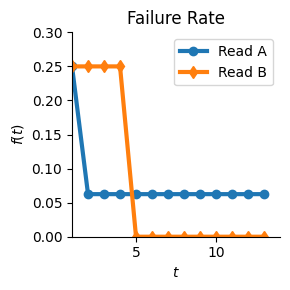

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})

plt.plot(range(1, max_T + 1), f_1[:max_T], marker='o', linewidth=3, label='Read A')
plt.plot(range(1, max_T + 1), f_2[:max_T], marker='d', linewidth=3, label='Read B')
plt.xlabel('$t$')
plt.ylabel('$f(t)$')
plt.title('Failure Rate')
plt.xlim(1, 14)
plt.ylim(0, 0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../../figures/failure_rate_example.png', dpi=300, transparent=True)

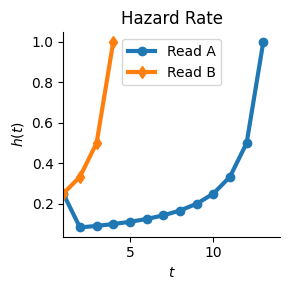

Bad pipe message: %s [b'\xcc\xd3\xc5I\x80>\x88\x9f\x16\xff\xa5\xe3Mx\x19\xbc\x19\x96\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x00']
Bad pipe message: %s [b'\xa2~\x08\xf9\xa9\x14[\x00"\xc3:\x16>\xd9\x15X\x80E\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})

plt.plot(range(1, max(T_1) + 1), h_1[:max(T_1)], marker='o', linewidth=3, label='Read A')
plt.plot(range(1, max(T_2) + 1), h_2[:max(T_2)], marker='d', linewidth=3, label='Read B')
plt.xlabel('$t$')
plt.ylabel('$h(t)$')
plt.title('Hazard Rate')
plt.xlim(1, 14)
plt.legend()
plt.tight_layout()
plt.savefig('../../figures/hazard_rate_example.png', dpi=300, transparent=True)

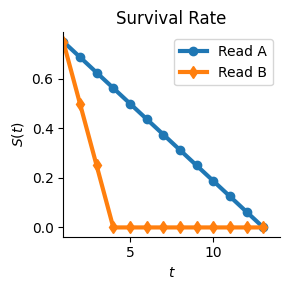

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})

plt.plot(range(1, max_T + 1), s_1[:max_T], marker='o', linewidth=3, label='Read A')
plt.plot(range(1, max_T + 1), s_2[:max_T], marker='d', linewidth=3, label='Read B')
plt.xlabel('$t$')
plt.ylabel('$S(t)$')
plt.title('Survival Rate')
plt.xlim(1, 14)
#plt.ylim(0, 0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../../figures/survival_rate_example.png', dpi=300, transparent=True)

In [15]:
h_2

[np.float64(0.0),
 np.float64(0.25),
 np.float64(0.3333333333333333),
 np.float64(0.5),
 np.float64(1.0),
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]